In [1]:
import matplotlib.pyplot as plt
import MLMC
import numpy as np

Nmin=30
M0=16
s=2

Lets now check the order of convergence of the Finite Volume Method. We do this by comparing the exact solution with a known manufactured solution

[0, 0.000945560515873013]
[1, 0.00024029589074806918]
[2, 6.055644914213809e-05]
[3, 1.5199067774629045e-05]
[4, 3.8072394019752338e-06]
[5, 9.527425388433383e-07]
[6, 2.383021349545098e-07]
[7, 5.959009112120942e-08]
[8, 1.4899342256523728e-08]
[9, 3.7250627026521933e-09]
[10, 9.312941764810296e-10]
[11, 2.3282708253893006e-10]


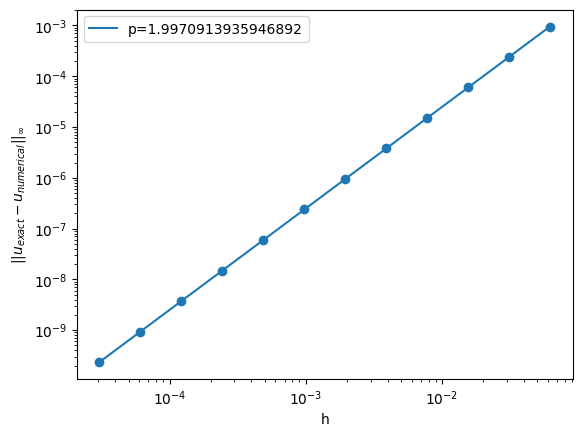

[[9.45560516e-04 2.40295891e-04 6.05564491e-05 1.51990678e-05
  3.80723940e-06 9.52742539e-07 2.38302135e-07 5.95900911e-08
  1.48993423e-08 3.72506270e-09 9.31294176e-10 2.32827083e-10]]
(array([-1.41076607,  1.99709139]), array([[3.24709742e-05, 4.35596367e-06],
       [4.35596367e-06, 6.61508134e-07]]))


In [ ]:
import error_analysis
m_vals=16*np.exp2(np.arange(12)).astype(int)
error_analysis.compare_to_exact_solution(MLMC.approximate_solution, MLMC.exact_solution, m_vals)


So the order of convergence is indeed 2. So $E(Q-Q_M) \approx C M^{-1}$, however it remains to find the constant C(which is needed for finding error_proportionality_constant)

In [ ]:
#We do not know the exact solution, so we just take M very large for a relatievly accurate 
M_low=16
M_high=1024
sample_num=1000
samples=MLMC.draw_Y_L_samples(16, M_high/M_low, sample_num, 1)
print(np.abs(np.mean(samples)*np.square(M_low)))



9.98146826238004
[-3.23480544e-02  6.63436704e-03 -5.39694976e-03  6.53380061e-03
  9.14254138e-02 -1.15540919e-02 -1.55266972e-01 -4.09315657e-02
  1.29191715e-02 -8.68606067e-03  1.41629071e-03 -5.82667197e-02
  3.27649364e-03 -5.55893501e-02  6.51221429e-02  8.43654261e-03
 -2.19306507e-01 -2.06629242e-02  6.33926099e-02  4.78998058e-02
 -3.04854570e-02 -4.00854517e-03  2.58057670e-04 -7.17125171e-03
 -1.10666702e-01  3.78979656e-02  1.00596081e-02  3.70019233e-02
 -1.34128793e-02 -1.16487521e-01  1.92894339e-02  5.69813445e-02
 -3.33542100e-02  1.17219921e-02 -1.52457749e-02 -6.10670066e-02
 -1.91070139e-02  7.40200035e-02 -2.56398283e-02  6.34167568e-02
 -2.71477355e-03 -1.81453951e-02 -1.66415665e-01  1.67248056e-02
 -1.59368219e-02 -1.34081424e-01 -1.70410841e-03  4.42730722e-02
  2.12368737e-02  8.62232273e-04  2.78800861e-03  4.42305541e-02
  2.83871188e-02  8.23049012e-05 -1.42367083e-02  1.51229246e-02
 -1.45616799e-01  2.78811056e-02 -8.10161057e-03 -7.60255024e-02
 -4.6547

The code approximates Q using a MLMC method. With the current settings it takes several hours to run. This is due to the fact that millions of samples are generated. If you increase eps(the fourth parameter of MLMC.MLMC) it will only take a few minutes. 

In [ ]:
(result, Y, N_vals, error_list, prev_N_vals)=MLMC.MLMC(Nmin, M0, s, 0.001)

Generating Q_L samples for M = 16:   0%|          | 0/30 [00:00<?, ?it/s]

Variance is: 0.0009996506823887843
error due to FVM is 0.003125
Total error is 0.004124650682388785


Variance is: 0.00017213062912696336
error due to FVM is 0.00078125
Total error is 0.0009533806291269634


Variance is: 4.7205124096142534e-06
error due to FVM is 0.0001953125
Total error is 0.00020003301240961426


Variance is: 1.4625697171939388e-07
error due to FVM is 4.8828125e-05
Total error is 4.897438197171939e-05


Below is the code for generating the plots.
First the plot for the variance

(5,)


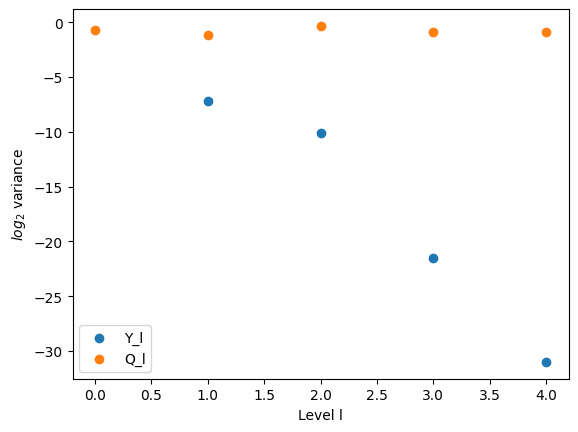

In [50]:
N_vals=16*np.exp2(np.arange(5)).astype(int)
sample_num=200
#Compute Q_L variance
Q_L=np.empty((N_vals.size, sample_num))
Q_vars=np.empty(N_vals.shape)

print(N_vals.shape)
for l in range(N_vals.size):
    M=M0*(s**l)
    Q_L[l]=MLMC.draw_Q_L_samples(M, sample_num)
    Q_vars[l]=Q_L[l].var()
#Compute variances of Y_L
Y_L=[np.empty(sample_num)]*len(N_vals)
Y_vars=np.empty(len(Y_L))
for l in range(len(Y_L)):
    Y_L[l]=MLMC.draw_Y_L_samples(16, 2, sample_num, l)
    Y_vars[l]=np.var(Y_L[l])
#Compute grid sizes
L_vals=np.arange(N_vals.size)
plt.scatter(L_vals[1:], np.log2(Y_vars[1:]), label="Y_l")
plt.scatter(L_vals, np.log2(Q_vars), label="Q_l")
plt.legend()
plt.xlabel("Level l")
plt.ylabel(r"$log _2$ variance")
plt.show()


Now the plot for the means

Text(0, 0.5, '$log_2$ |mean|')

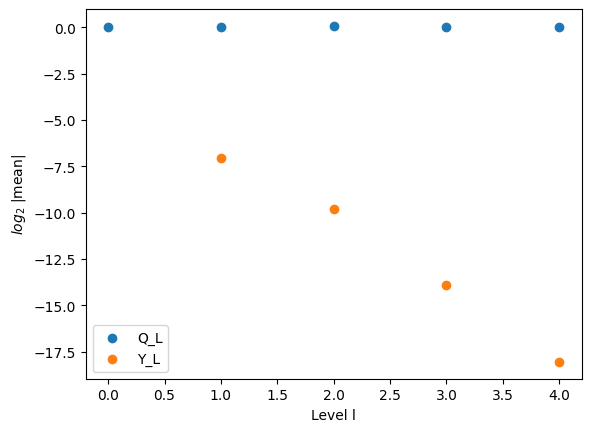

In [51]:
Q_means=np.empty(Q_vars.shape)
for l in range(Q_L.shape[0]):
    Q_means[l]=Q_L[l].mean()
Y_means=np.empty(len(Y_L)-1)
for l in range(1, len(Y_L)):
    Y_means[l-1]=np.mean(Y_L[l])
plt.scatter(L_vals, np.log2(np.abs(Q_means)), label="Q_L")
plt.scatter(L_vals[1:], np.log2(np.abs(Y_means)), label="Y_L")
plt.legend()
plt.xlabel("Level l")
plt.ylabel(r"$log_2$ |mean|")

Next is the number of samples on each level(for various grid sizes)

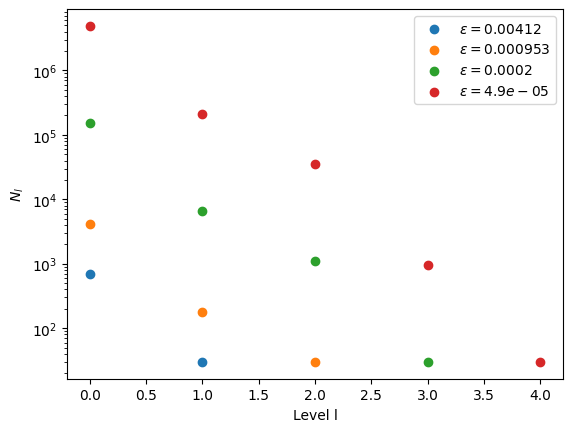

In [33]:
rounded_errs=np.array(error_list)
for i in range(len(error_list)):
    plt.scatter(np.linspace(0, i+1, i+2, True), prev_N_vals[i], label=r"$\epsilon = " + str(round(error_list[i], 2-np.min((0, np.floor(np.log10(error_list[i])).astype(int))))) + "$")
plt.semilogy()
plt.legend()
plt.xlabel("Level l")
plt.ylabel(r"$N_l$")
plt.show()

For the next plot we will compare the cost of the standard Monte Carlo Method with the cost for the multilevel Monte Carlo method

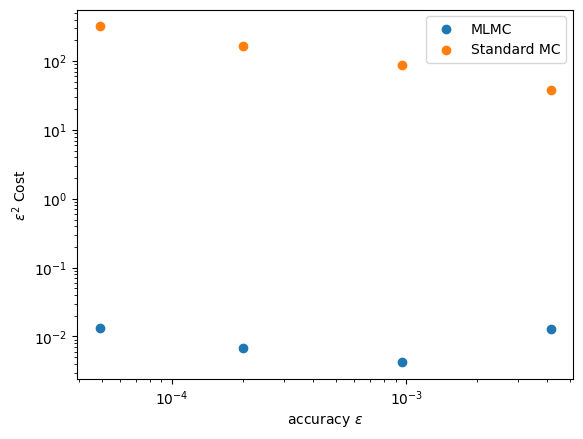

In [49]:
err_list_np=np.array(error_list)
#Compute MLMC cost
MLMC_cost=np.empty(len(error_list))
for i in range (len(error_list)):
    MLMC_cost[i]=np.sum(np.exp2(np.arange(i+2))*prev_N_vals[i])
#Compute standard MC cost
standard_MC_cost=np.empty(len(error_list))
for i in range(len(error_list)):
    #Compute level
    M_l=np.ceil(np.sqrt(2.*MLMC.error_proportionality_constant/error_list[i]))
    #Compute variance at this level
    M_l_samples=MLMC.draw_Q_L_samples(int(M_l), 1000)
    M_l_var=np.var(M_l_samples)
    #Compute cost
    standard_MC_cost[i]=M_l_var*2./np.square(error_list[i])*M_l
#Plot results
plt.scatter(error_list, np.square(err_list_np)*MLMC_cost, label="MLMC")
plt.scatter(error_list, np.square(err_list_np)*standard_MC_cost, label="Standard MC")
plt.legend()
plt.loglog()
plt.xlabel(r"accuracy $\epsilon$")
plt.ylabel(r"$\epsilon ^2$ Cost")
plt.show()

In [48]:
result

1.0076166436590779